In [2]:
# Python packages we will use in this notebook
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image
from scipy.integrate import simpson
from seisflows.tools.model import Model 
np.float_ = np.float64
from pyatoa import Config, Manager, logger
from pysep.utils.io import read_sem
import pandas as pd
import pickle as pkl
import pyfm2d
from scipy.interpolate import RectBivariateSpline
import datetime
from glob import glob
from scipy import signal
import h5py
import dascore as dc
import obspy
import emcee
import math
import scipy
import pygimli as pg
import pygimli.meshtools as mt
from pygimli.viewer.mpl import drawMesh
import pyekfmm as fmm
import ttcrpy

import gmsh


# plt.rcdefaults()
# plt.style.use('seaborn-v0_8-paper')
# plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica']})

from ttcrpy.tmesh import Mesh2d

from pygimli.physics import TravelTimeManager
%matplotlib widget


In [3]:
def obspy_stream_from_das(data, attrs,times):
    stats_default = {
        'network':'eastwind',
        'station':'',
        'location':'',
        'channel':'DAS',
        'starttime':times[0].strftime('%Y-%m-%dT%H:%M:%S.%fZ'),
        'endtime':times[-1].strftime('%Y-%m-%dT%H:%M:%S.%fZ'),
        'sampling_rate':attrs['PulseRate'],
        'delta':1/attrs['PulseRate'],
        'npts':0,
        'calib':1.0
    }

    streams = []
    for n,i in enumerate(data.T):
        tr = obspy.Trace(data=i,header=stats_default)
        # tr.stats.station = f'Channel {n}'
        tr.stats.npts = len(i)

        st = obspy.Stream(tr)
        streams.append(st)
    return streams

def obspy_stream_from_das(data, attrs,times):
    stats_default = {
        'network':'eastwind',
        'station':'',
        'location':'',
        'channel':'DAS',
        'starttime':times[0].strftime('%Y-%m-%dT%H:%M:%S.%fZ'),
        'endtime':times[-1].strftime('%Y-%m-%dT%H:%M:%S.%fZ'),
        'sampling_rate':attrs['PulseRate'],
        'delta':1/attrs['PulseRate'],
        'npts':0,
        'calib':1.0
    }

    streams = []
    for n,i in enumerate(data.T):
        tr = obspy.Trace(data=i,header=stats_default)
        # tr.stats.station = f'Channel {n}'
        tr.stats.npts = len(i)

        st = obspy.Stream(tr)
        streams.append(st)
    return streams

def sintela_to_datetime(sintela_times):
    '''
    returns an array of datetime.datetime 
    ''' 
    
    days1970 = datetime.datetime.date(datetime.datetime(1970, 1, 1)).toordinal()

    # Vectorize everything
    converttime = np.vectorize(datetime.datetime.fromordinal)
    addday_lambda = lambda x : datetime.timedelta(days=x)
    adddays = np.vectorize(addday_lambda )
    
    day = days1970 + sintela_times/1e6/60/60/24
    thisDateTime = converttime(np.floor(day).astype(int))
    dayFraction = day-np.floor(day)
    thisDateTime = thisDateTime + adddays(dayFraction)

    return thisDateTime


def time_fixer_4_fk(times):
    times_copy = times.copy()
    new_format_times = []
    for i in times_copy:
        if round(i.microsecond/500)*500 == 1000000:
            microsecond = 0
            second = i.second + 1
            minute = i.minute
            hour = i.hour
            day = i.day
            if second == 60:
                second = 0
                minute = minute+1

            if minute == 60:
                minute = 0
                hour=hour+1
            
            if hour == 24:
                hour = 0
                day = day+1
            
        else:
            microsecond = int(round(i.microsecond/500)*500)
            second = i.second
            minute = i.minute
            hour = i.hour
            day = i.day

        new_format_times.append(datetime.datetime(year=i.year,
                                                month=i.month,
                                                day=day,
                                                hour=hour,
                                                minute=minute,
                                                second=second,
                                                microsecond=microsecond))
    return new_format_times

def chan_norm(das_data):
    data_normed = (das_data - np.mean(das_data, axis=0))/np.std(das_data, axis=0).T

    return data_normed

#### Load the picks and source locations

In [4]:
channel_locations = np.array(pd.read_csv('/home/scoped/eastwind_v2/cable_geometry/Eastwind_channel_locations.txt', sep=' ', header=None))

In [5]:
# # with open('../event_locations/good_event_locations.pkl', 'rb') as f:
# #     all_locations_good = pkl.load(f)

with open('../auto_picked_events/pws_picks.pkl', 'rb') as f:
    # Serialize and write the data to the file
    all_picks = pkl.load(f)

In [6]:
### phase weighting channels ###

chan_start = 11
num_to_stack = 5
channel_locations_4stacking = np.reshape(channel_locations[:,:2][chan_start:], (int(channel_locations[:,:2][chan_start:].shape[0]/num_to_stack), num_to_stack, 2))

chan_stack_ids = np.arange(chan_start, channel_locations[:,:2][:].shape[0], 1)
chan_stack_ids = np.reshape(chan_stack_ids, channel_locations_4stacking.shape[:2])

In [7]:
with open('/home/scoped/eastwind_v2/event_locations/pws_event_locations.pkl', 'rb') as f:
    all_locations_good = pkl.load(f)
mean_params_good = np.mean(np.array(list(all_locations_good.values())),axis=1)
std_params_good = np.std(np.array(list(all_locations_good.values())),axis=1)

In [8]:
# event_num = 33 # big event
# event_num = 35 #another big event
# event_num = 37 # back to back events t = -1, t2 = 2
# event_num = 44, big event definitely reflections
event_num = 44

In [9]:

event_datetime = datetime.datetime.fromtimestamp(np.min(all_picks['Event '+str(event_num)][1]), tz=datetime.timezone.utc)
wanted_file_str = 'Eastwind_decimator_2024-12-'+str(event_datetime.day)+'_'+event_datetime.strftime("%H")+"."+event_datetime.strftime("%M")+"*"

file = glob('/mnt/'+wanted_file_str)[0]

f = h5py.File(file)

attrs = f['Acquisition'].attrs
fs = attrs['PulseRate']
data = f['Acquisition']['Raw[0]']['RawData'][:]
this_time = f['Acquisition']['Raw[0]']['RawDataTime'][:]
times = sintela_to_datetime(this_time)
x = np.linspace(0,data.shape[1],data.shape[1]) * attrs['SpatialSamplingInterval']

bp_top = 500
bp_bottom = 10
downsample_rate = int(fs/bp_top)
#filter by freq
sos = signal.butter(10, [bp_bottom,bp_top], 'bp', fs=fs, output='sos')
filtered = signal.sosfiltfilt(sos, data, axis=0)
# #FK filter
# new_format_times = time_fixer_4_fk(times)
# dims = ('time', 'distance')
# patch = dc.Patch(data=filtered, coords=dict(time=[np.datetime64(i) for i in new_format_times], distance=x), dims=dims)
# filt_cutoffs = np.array([0, 3500, 4500,np.inf]) # try to just filter for the p-wave

# fk_filtered = patch.slope_filter(filt=filt_cutoffs)
# fk_filtered_data = np.array(fk_filtered.data)

#normalize
data_normed_filtered = chan_norm(filtered)

t_start = times[0].replace(tzinfo = datetime.timezone.utc)
slice_start = int(((event_datetime - t_start).total_seconds() - 1) * fs)
slice_end = int(((event_datetime - t_start).total_seconds() + 5) * fs)


event_data = data_normed_filtered[slice_start:slice_end,:]
t_event = times[slice_start:slice_end]




In [21]:
stacked_waveforms = []
stacked_chan = []

for chans in chan_stack_ids:

    streams = obspy_stream_from_das(event_data[:,chans], attrs, t_event)


    st = streams[0]
    for n in range(len(streams) - 1):
        st+=streams[n+1]
    stacked_waveform = st.stack(stack_type=('pw',0))
    tr = stacked_waveform[0]
    stacked_waveforms.append(tr.data)
    stacked_chan.append(int(np.rean(chans)))

stacked_waveforms = np.array(stacked_waveforms).T
stacked_chan = np.array(stacked_chan)

NameError: name 'chan_stack_ids' is not defined

NameError: name 't_event' is not defined

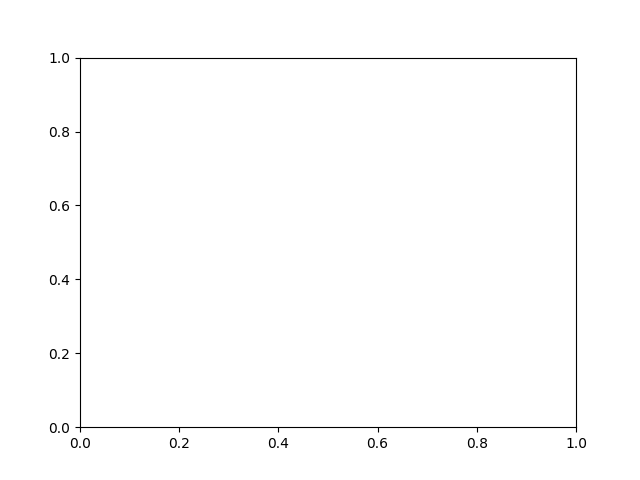

In [ ]:
fig,ax = plt.subplots()

ax.pcolormesh(stacked_chan, t_event, stacked_waveforms[:-1,:-1], vmin=-1, vmax=1, cmap='seismic')

## stack all channels

In [ ]:
streams = obspy_stream_from_das(event_data[:,:], attrs, t_event)

st = streams[0]
for n in range(len(streams) - 1):
    st+=streams[n+1]
stacked_waveform = st.stack(stack_type=('pw',0))
tr = stacked_waveform[0]

NameError: name 'event_data' is not defined

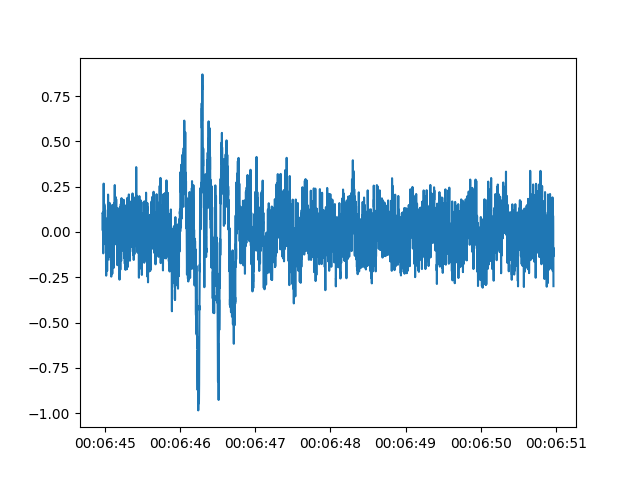

In [ ]:
fig,ax = plt.subplots()

ax.plot(t_event,tr)

# Stacking based on the picks

In [18]:
with open('../manual_picked_events/manual_picks_event_'+str(event_num)+'.pkl', 'rb') as f:
    channel_picks = pkl.load(f)

In [19]:
datetime_of_picks = [datetime.datetime.fromtimestamp(i, tz=datetime.timezone.utc) for i in channel_picks[1]]

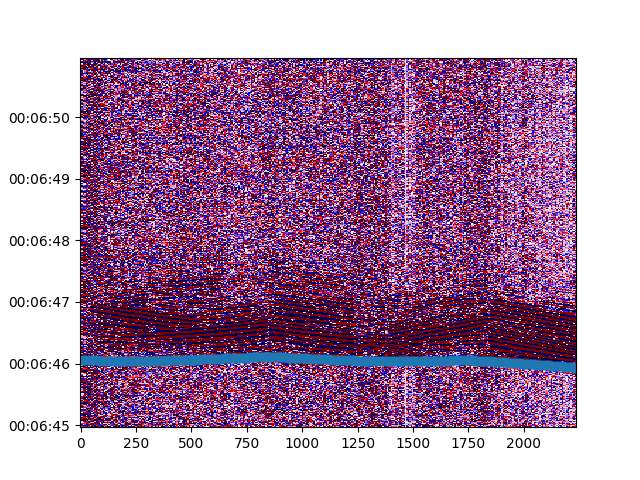

In [32]:
fig,ax = plt.subplots()

ax.pcolormesh(np.arange(0,351,1)*attrs["SpatialSamplingInterval"], t_event, event_data[:,:], vmin=-1, vmax=1, cmap='seismic')
ax.scatter(np.array(channel_picks[0])*attrs["SpatialSamplingInterval"],datetime_of_picks)

In [12]:
f_arrival = np.round((channel_picks[1] - np.min(channel_picks[1])) * fs)

In [13]:
event_data[np.array(f_arrival,dtype=int):np.array(f_arrival-f_arrival.max(),dtype=int),:]

TypeError: only integer scalar arrays can be converted to a scalar index

In [99]:
slant_stacked = np.zeros((int(event_data.shape[0]-f_arrival.max()),event_data.shape[1]))

for n,data_slice in enumerate(event_data[:,:].T):

    if f_arrival[n] == f_arrival.max():
        slant_stacked[:,n] = (data_slice[int(f_arrival[n]):]-np.mean(data_slice[int(f_arrival[n]):]))/np.std(data_slice[int(f_arrival[n]):])
    else:
        slant_stacked[:,n] = (data_slice[int(f_arrival[n]):int(f_arrival[n]-f_arrival.max())]-np.mean(data_slice[int(f_arrival[n]):int(f_arrival[n]-f_arrival.max())]))/np.std(data_slice[int(f_arrival[n]):int(f_arrival[n]-f_arrival.max())])


# np.array(f_arrival-f_arrival.max(),dtype=int)

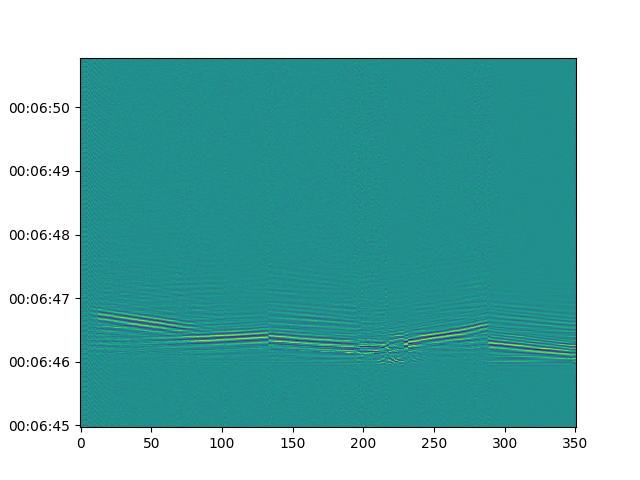

In [100]:
fig,ax = plt.subplots()

ax.pcolormesh(np.arange(0,351,1), t_event[:-int(f_arrival.max())], slant_stacked)

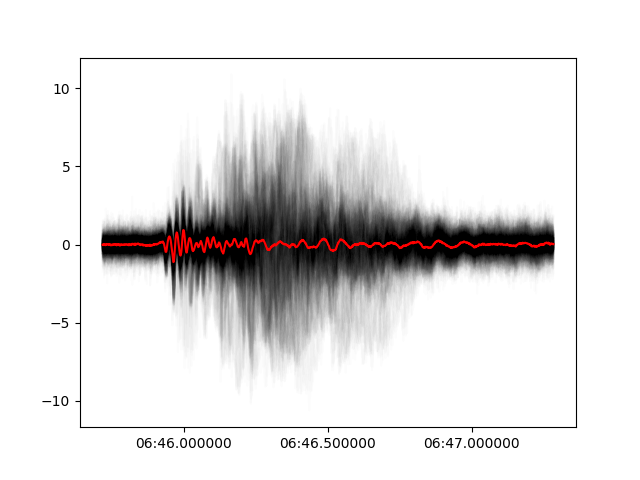

In [101]:
fig,ax = plt.subplots()

ax.plot(t_event[1500:-int(f_arrival.max())-7000], slant_stacked[1500:-7000,:], '-k', alpha=0.01)
ax.plot(t_event[1500:-int(f_arrival.max())-7000], np.mean(slant_stacked[1500:-7000,:], axis=1), '-r')

plt.show()

In [102]:
median_event_spectrogram = []

for i in slant_stacked[1500:-7000,:].T:
    f, t, Sxx = scipy.signal.spectrogram(i, fs=fs, nperseg=518, noverlap=500)
    median_event_spectrogram.append(Sxx)

median_event_spectrogram = np.median(np.array(median_event_spectrogram), axis=0)

In [103]:
secs = [i.total_seconds() for i in t_event[1500:-int(f_arrival.max())-7000] - t_event[1500]]

(-5.0, 5.0)

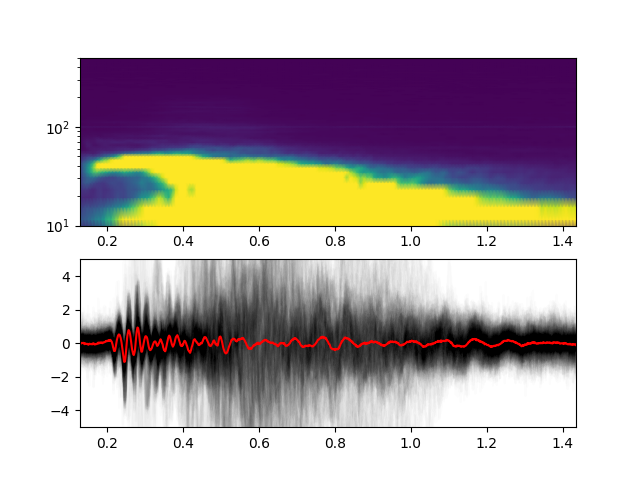

In [104]:
fig,ax = plt.subplots(2,1)

ax[0].pcolormesh(t, f, median_event_spectrogram, shading='gouraud', 
                vmin=np.percentile(median_event_spectrogram, 25), vmax=.01)
ax[0].set_yscale('log')
ax[0].set_ylim(10, 5e2)

ax[1].plot(secs, slant_stacked[1500:-7000,:], '-k', alpha=0.01)
ax[1].plot(secs, np.mean(slant_stacked[1500:-7000,:], axis=1), '-r')

ax[1].set_xlim(t[0], t[-1])
ax[1].set_ylim([-5,5])

In [18]:
streams = obspy_stream_from_das(slant_stacked, attrs, t_event[:-int(f_arrival.max())])

st = streams[0]
for n in range(len(streams) - 1):
    st+=streams[n+1]
stacked_waveform = st.stack(stack_type=('pw',0))
tr = stacked_waveform[0]

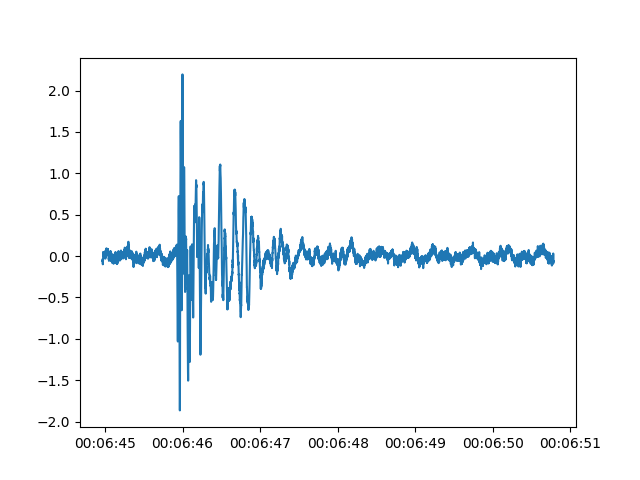

In [19]:
fig,ax = plt.subplots()

ax.plot(t_event[:-int(f_arrival.max())],tr)

(array([[7.46225942e-05, 1.38843568e-05, 1.32401609e-05, ...,
         4.05236762e-04, 9.30506053e-05, 4.85194922e-07],
        [8.35282232e-05, 4.69869783e-05, 5.05542512e-05, ...,
         3.68446848e-04, 1.37192626e-04, 3.31329837e-05],
        [2.83529952e-05, 4.89681905e-07, 2.52064359e-05, ...,
         3.47365716e-05, 1.03068050e-05, 4.40891054e-06],
        ...,
        [5.72629156e-18, 2.56396110e-19, 3.90593262e-19, ...,
         1.35921833e-17, 1.71968202e-18, 8.23292801e-19],
        [5.57225605e-18, 6.78082888e-20, 3.02579614e-19, ...,
         1.35353217e-17, 1.56322993e-18, 7.98615922e-19],
        [2.76052916e-18, 2.60317071e-21, 1.36697341e-19, ...,
         6.75821995e-18, 7.55652494e-19, 3.95229072e-19]], shape=(129, 204)),
 array([   0.    ,    7.8125,   15.625 ,   23.4375,   31.25  ,   39.0625,
          46.875 ,   54.6875,   62.5   ,   70.3125,   78.125 ,   85.9375,
          93.75  ,  101.5625,  109.375 ,  117.1875,  125.    ,  132.8125,
         140.625 ,  148.4

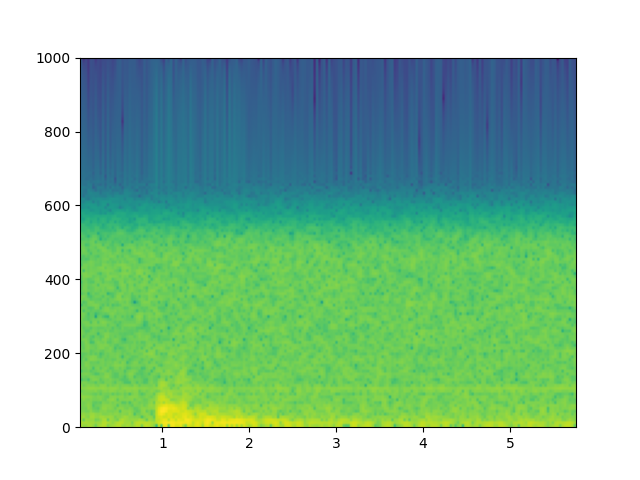

In [21]:
fig,ax = plt.subplots()

ax.specgram(tr, Fs=fs, NFFT=256, noverlap=200, cmap='viridis')

In [400]:
all_specs = []

for i in range(slant_stacked.shape[1]):
    f, t, Sxx = scipy.signal.spectrogram(slant_stacked[:,i], fs=fs, nperseg=256, noverlap=128)
    all_specs.append(Sxx)

mean_event_spec = np.median(np.array(all_specs),axis=0)

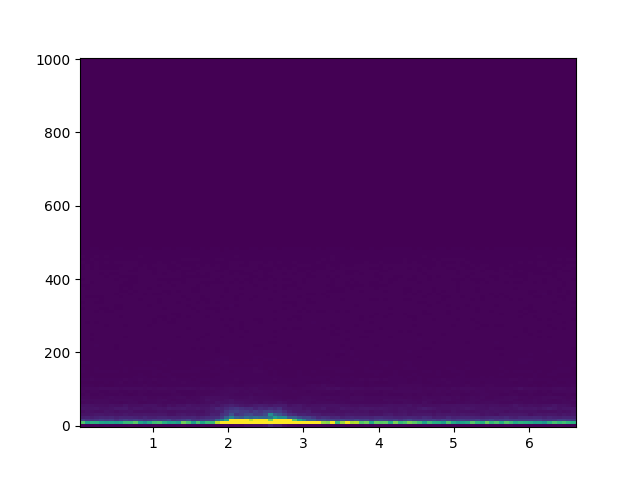

In [319]:
fig,ax=plt.subplots()
ax.pcolormesh(t,f,mean_event_spec, vmin=0, vmax=.01, cmap='viridis')

In [113]:
np.log10(Sxx).mean()

np.float64(-7.087257704514474)

(np.float64(20076.004695804444), np.float64(20076.004716059073))

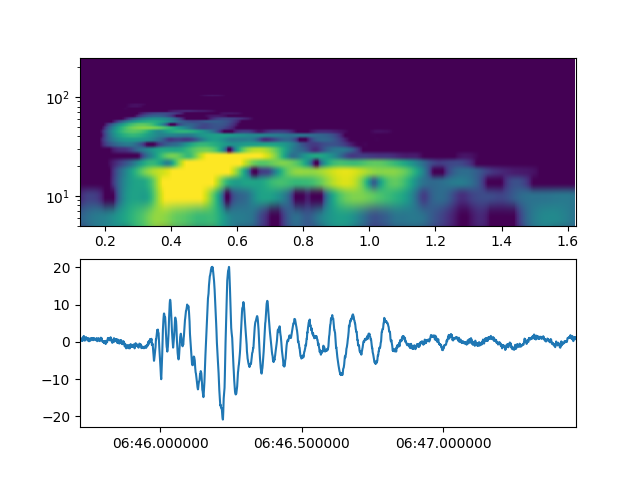

In [11]:
channel = 330

f, t, Sxx = scipy.signal.spectrogram(event_data[1500:5000,channel], fs=fs, nperseg=256, noverlap=200)

fig,ax = plt.subplots(2,1)

# ax[0].pcolormesh(t,f,Sxx, vmin=0, vmax=1, cmap='viridis')

# ax[0].pcolormesh(t,f,Sxx, vmin=-160, vmax=0, cmap='viridis')
ax[0].specgram(event_data[1500:5000,channel], Fs=fs, NFFT=512, noverlap=500, cmap='viridis',vmin=-20, vmax=5)

ax[0].set_yscale('log')
ax[0].set_ylim([50e-1,250])

ax[1].plot(t_event[1500:5000],event_data[1500:5000,channel])
ax[1].set_xlim([t_event[1500],t_event[5000]])

In [83]:
timestamp_ = [i.timestamp() for i in t_event]
dt_upsampled =[datetime.datetime.fromtimestamp(i, tz=datetime.timezone.utc) for i in np.linspace(timestamp_[0], timestamp_[-1], num=len(timestamp_)*10)]

In [84]:
f = scipy.interpolate.interp1d(timestamp_, event_data[:,channel])
new_y = f(np.linspace(timestamp_[0], timestamp_[-1], num=len(timestamp_)*10))

(np.float64(20076.004695804444), np.float64(20076.004716059073))

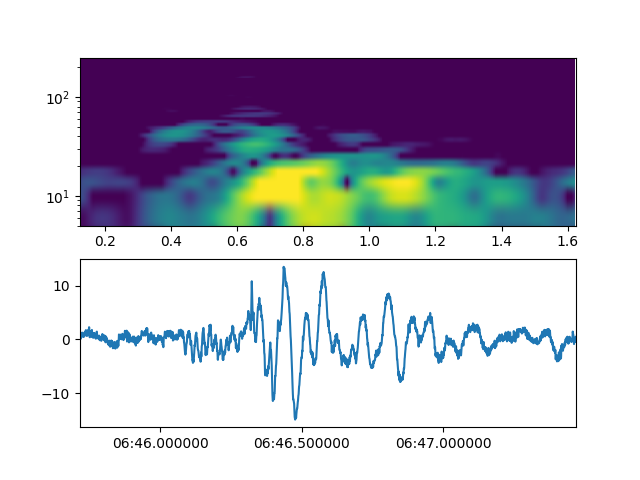

In [15]:
channel = 160

f, t, Sxx = scipy.signal.spectrogram(event_data[1500:5000,channel], fs=fs, nperseg=256, noverlap=200)

fig,ax = plt.subplots(2,1)

# ax[0].pcolormesh(t,f,Sxx, vmin=0, vmax=1, cmap='viridis')

# ax[0].pcolormesh(t,f,Sxx, vmin=-160, vmax=0, cmap='viridis')
ax[0].specgram(event_data[1500:5000,channel], Fs=fs, NFFT=512, noverlap=500, cmap='viridis',vmin=-20, vmax=5)

ax[0].set_yscale('log')
ax[0].set_ylim([50e-1,250])

ax[1].plot(t_event[1500:5000],event_data[1500:5000,channel])
ax[1].set_xlim([t_event[1500],t_event[5000]])

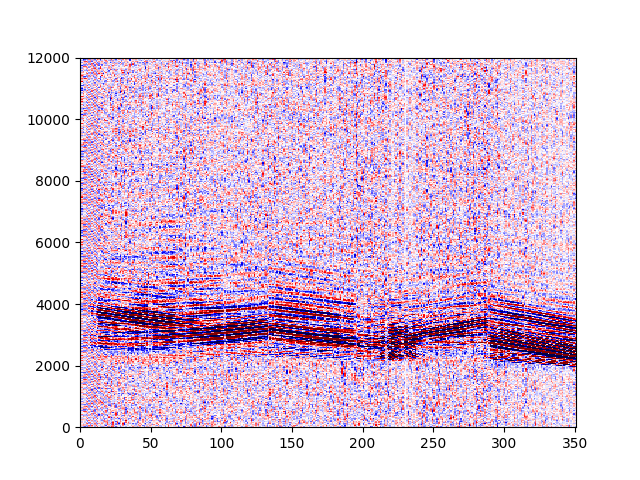

In [92]:
fig, ax = plt.subplots()

ax.pcolorfast(event_data[:,:], vmin=-5, vmax=5, cmap='seismic')

# Load the locations

In [10]:
with open('../locations/event_44_location.pkl', 'rb') as f:
    event_location = pkl.load(f)

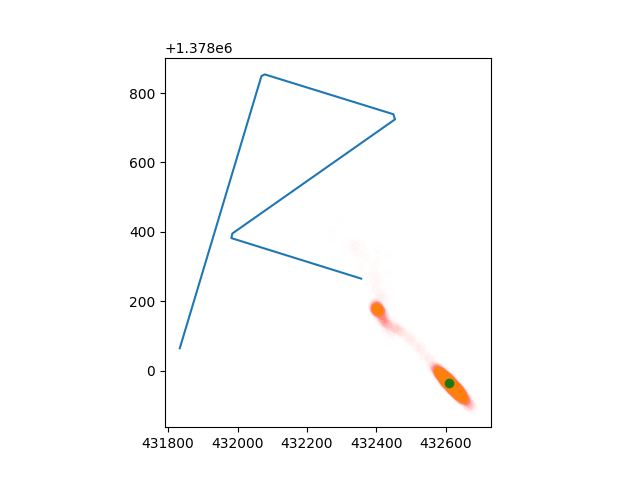

In [25]:
fig,ax = plt.subplots()
ax.scatter(np.median(event_location[:,0]), np.median(event_location[:,1]))
ax.scatter(event_location[:,0], event_location[:,1], alpha=0.005)
ax.plot(channel_locations[:,0], channel_locations[:,1])
ax.set_aspect('equal')


In [ ]:
channel_locations_cut_x = np.concatenate((channel_locations[:250,0], channel_locations[280:,0]))
channel_locations_cut_y = np.concatenate((channel_locations[:250,1], channel_locations[280:,1]))

In [ ]:
distances = np.sqrt((channel_locations[:,0] - np.median(event_location[:,0]))**2 + (channel_locations[:,1] - np.median(event_location[:,1]))**2)


In [13]:
distances_sorted = np.sort(distances)

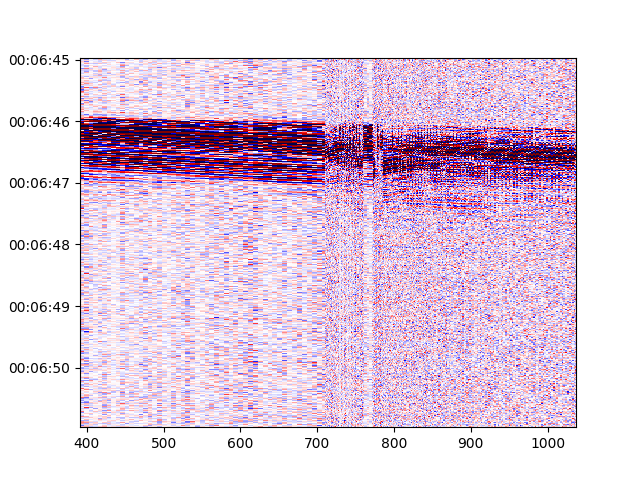

In [14]:
fig, ax = plt.subplots()

ax.pcolormesh(distances_sorted, t_event, event_data[:,np.argsort(distances)], vmin=-5, vmax=5, cmap='seismic')

ax.invert_yaxis()

(array([2.000e+00, 7.000e+00, 1.200e+01, 8.000e+00, 3.000e+01, 8.150e+03,
        1.405e+03, 1.600e+02, 5.110e+02, 1.470e+02]),
 array([2736.79389654, 2919.49517671, 3102.19645689, 3284.89773706,
        3467.59901723, 3650.30029741, 3833.00157758, 4015.70285776,
        4198.40413793, 4381.1054181 , 4563.80669828]),
 <BarContainer object of 10 artists>)

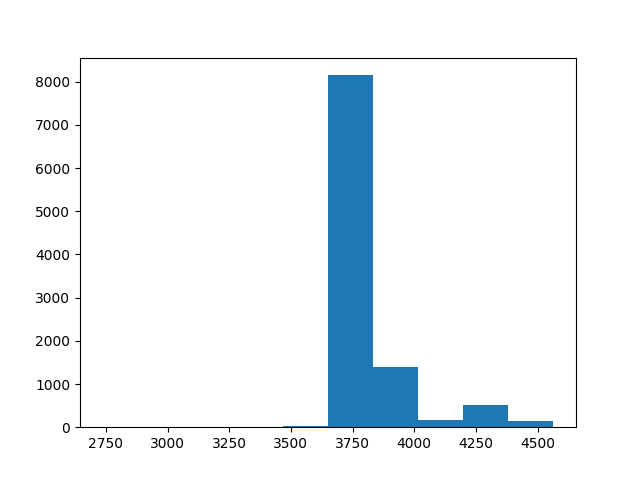

In [26]:
fig,ax = plt.subplots()

ax.hist(event_location[:,-1])

(array([   5.,   42.,  210.,  604., 1384., 2324., 2920., 1835.,  815.,
         293.]),
 array([-206.63721   , -175.98673751, -145.33626502, -114.68579253,
         -84.03532004,  -53.38484755,  -22.73437506,    7.91609743,
          38.56656992,   69.21704241,   99.8675149 ]),
 <BarContainer object of 10 artists>)

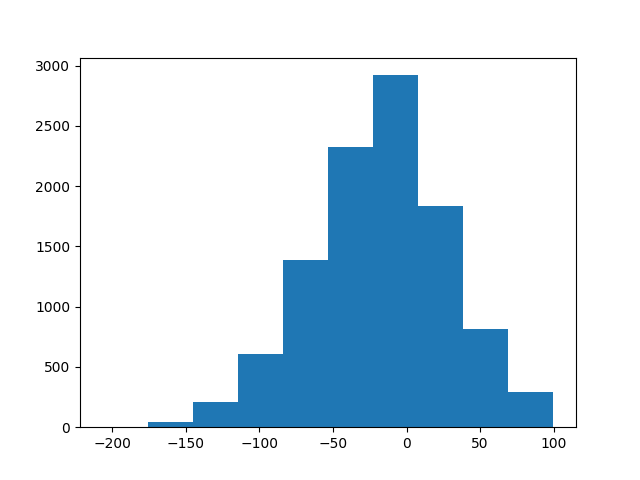

In [27]:
fig,ax = plt.subplots()

ax.hist(event_location[:,2])

In [29]:
event_location

array([[ 4.32354861e+05,  1.37833235e+06, -7.80221143e+01,
         1.73456681e+09,  3.43588024e+03],
       [ 4.32336980e+05,  1.37836031e+06, -8.78716801e+01,
         1.73456681e+09,  3.04502461e+03],
       [ 4.32350759e+05,  1.37836534e+06, -1.02322678e+02,
         1.73456681e+09,  3.27952579e+03],
       ...,
       [ 4.32588486e+05,  1.37797922e+06, -7.01353796e+01,
         1.73456681e+09,  3.85009431e+03],
       [ 4.32608667e+05,  1.37797158e+06,  2.00274614e+01,
         1.73456681e+09,  3.78324222e+03],
       [ 4.32633437e+05,  1.37795816e+06, -9.95257812e+00,
         1.73456681e+09,  3.79659582e+03]], shape=(10432, 5))

/opt/conda/lib/python3.10/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


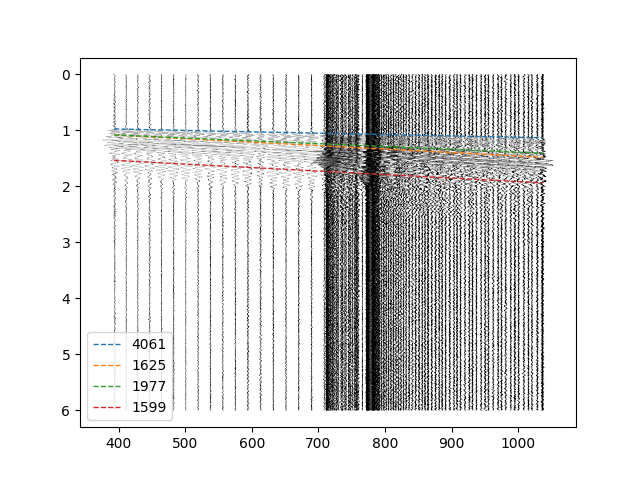

In [15]:
fig,ax = plt.subplots()
for n in np.arange(0,len(distances_sorted),3):
    ax.plot(distances_sorted[n]+event_data[:,np.argsort(distances)][:,n], [i.total_seconds() for i in t_event - t_event[0]], '-k',lw=.1)

vel=(1036.9765126491482-393)/(1.132616-0.974035)
ax.plot([393,1036.9765126491482],
        [0.974035, 1.132616], ls='--', lw=1, label=str(round(vel)))

vel=(1036.9765126491482-393)/(1.47881-1.082502)
ax.plot([393,1036.9765126491482],
        [1.082502, 1.47881], ls='--', lw=1, label=str(round(vel)))

vel=(1036.9765126491482-393)/(1.407-1.0813)
ax.plot([393,1036.9765126491482],
        [1.0813, 1.407], ls='--', lw=1, label=str(round(vel)))

vel=(1036.9765126491482-393)/(1.9370-1.53435)
ax.plot([393,1036.9765126491482],
        [1.5343, 1.9370], ls='--', lw=1, label=str(round(vel)))


ax.legend()
ax.invert_yaxis()

# Compare to model

In [27]:
arrival_times = {}

In [28]:

gmsh.initialize()

gmsh.clear()
mesh_size = 0.1

mesh_size2 = 0.2*mesh_size

### ORIGINAL POINTS ###
# points for the surface
# p1 = gmsh.model.geo.addPoint(0.0, 0.0, 0.0, meshSize=mesh_size)
# p2 = gmsh.model.geo.addPoint(1.0, 0.0, 0.0, meshSize=mesh_size)
# p3 = gmsh.model.geo.addPoint(5.0, 0.0, -2, meshSize=mesh_size) #original: -2
# p4 = gmsh.model.geo.addPoint(10.0, 0.0, 2, meshSize=mesh_size) #original: 2
# p5 = gmsh.model.geo.addPoint(14.0, 0.0, 0.0, meshSize=mesh_size)
# p6 = gmsh.model.geo.addPoint(15.0, 0.0, 0.0, meshSize=mesh_size)

# points for the surface
p1 = gmsh.model.geo.addPoint(0.0, 0.0, 0.0, meshSize=mesh_size)
p2 = gmsh.model.geo.addPoint(.1, 0.0, 0.0, meshSize=mesh_size)
p3 = gmsh.model.geo.addPoint(.5, 0.0, -.001, meshSize=mesh_size) #original: -2
p4 = gmsh.model.geo.addPoint(1., 0.0, .001, meshSize=mesh_size) #original: 2
p5 = gmsh.model.geo.addPoint(1.4, 0.0, 0.0, meshSize=mesh_size)
p6 = gmsh.model.geo.addPoint(1.5, 0.0, 0.0, meshSize=mesh_size)

# points for the interface between the layers, we use a smaller
# mesh_size to get a denser distribution along the interface

### ORIGINAL POINTS ###
# p7 = gmsh.model.geo.addPoint(15.0, 0.0, 3.0, meshSize=mesh_size2)
# p8 = gmsh.model.geo.addPoint(10.0, 0.0, 2.0, meshSize=mesh_size2)
# p9 = gmsh.model.geo.addPoint(5.0, 0.0, 4.0, meshSize=mesh_size2)
# p10 = gmsh.model.geo.addPoint(0.0, 0.0, 3.0, meshSize=mesh_size2)

p7 = gmsh.model.geo.addPoint(1.5, 0.0, .26, meshSize=mesh_size2)
p8 = gmsh.model.geo.addPoint(1., 0.0, .259, meshSize=mesh_size2)
p9 = gmsh.model.geo.addPoint(.5, 0.0, .261, meshSize=mesh_size2)
p10 = gmsh.model.geo.addPoint(0.0, 0.0, .26, meshSize=mesh_size2)

###Original points for the bottom
# # bottom
# p11 = gmsh.model.geo.addPoint(15.0, 0.0, 6.0, meshSize=mesh_size)
# p12 = gmsh.model.geo.addPoint(0.0, 0.0, 6.0, meshSize=mesh_size)

# bottom
p11 = gmsh.model.geo.addPoint(1.5, 0.0, 1.0, meshSize=mesh_size)
p12 = gmsh.model.geo.addPoint(0.0, 0.0, 1.0, meshSize=mesh_size)

# Get curved surface using BSplines
surf_tag = gmsh.model.geo.addBSpline([p1, p2, p3, p4, p5, p6], tag=10)
gmsh.model.geo.addLine(p6, p7, tag=11)
refl_tag = gmsh.model.geo.addBSpline([p7, p8, p9, p10], tag=12)
gmsh.model.geo.addLine(p10, p1, tag=13)

gmsh.model.geo.addLine(p7, p11, tag=14)
gmsh.model.geo.addLine(p11, p12, tag=15)
gmsh.model.geo.addLine(p12, p10, tag=16)

gmsh.model.geo.addCurveLoop([10, 11, 12, 13], tag=21)
gmsh.model.geo.addCurveLoop([-12, 14, 15, 16], tag=22)

gmsh.model.geo.addPlaneSurface([21], tag=31)
gmsh.model.geo.addPlaneSurface([22], tag=32)

gmsh.model.geo.synchronize()

# create physical entities to be able to retrieve node 
# coordinates at the surface & interface, and to assign
# velocity
pl1 = gmsh.model.addPhysicalGroup(1, [surf_tag])
pl2 = gmsh.model.addPhysicalGroup(1, [refl_tag])

ps1 = gmsh.model.addPhysicalGroup(2, [31])
ps2 = gmsh.model.addPhysicalGroup(2, [32])

gmsh.model.setPhysicalName(1, pl1, "surface")
gmsh.model.setPhysicalName(1, pl2, "reflector")
gmsh.model.setPhysicalName(2, ps1, "layer_1")
gmsh.model.setPhysicalName(2, ps2, "layer_2")

# We can then generate a 2D mesh...
gmsh.model.mesh.generate(2)

Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 10 (Nurb)
Info    : [ 20%] Meshing curve 11 (Line)
Info    : [ 30%] Meshing curve 12 (Nurb)
Info    : [ 50%] Meshing curve 13 (Line)
Info    : [ 60%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : Done meshing 1D (Wall 0.0205349s, CPU 0.021039s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 31 (Plane, Frontal-Delaunay)
Info    : [ 60%] Meshing surface 32 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0618792s, CPU 0.058817s)
Info    : 1042 nodes 2157 elements


In [29]:

slowness = []
triangles = []

surface = []     # node coordinates at the surface
reflector = []   # node coordinates at the interface

for dim, tag in gmsh.model.getEntities():
    
    if dim == 1:
        # get the nodes on the BSplines
        elemTypes, elemTags, elemNodeTags = gmsh.model.mesh.getElements(dim, tag)
        physicalTags = gmsh.model.getPhysicalGroupsForEntity(dim, tag)
        if len(physicalTags) == 0:
            continue
        name = gmsh.model.getPhysicalName(dim, physicalTags[0])
        
        if name == 'surface':
            for tag in np.unique(elemNodeTags[0]):
                node = gmsh.model.mesh.getNode(tag)
                surface.append(node[0])
        elif name == 'reflector':
            # get coordinates of the nodes on the interface
            for tag in np.unique(elemNodeTags[0]):
                node = gmsh.model.mesh.getNode(tag)
                reflector.append(node[0])
        
    elif dim == 2:
        # assign velocity
        elemTypes, elemTags, elemNodeTags = gmsh.model.mesh.getElements(dim, tag)
        physicalTags = gmsh.model.getPhysicalGroupsForEntity(dim, tag)
        name = gmsh.model.getPhysicalName(dim, physicalTags[0])
        
        for n in range(len(elemTags[0])):
            t = elemNodeTags[0][3*n:(3*n+3)]
            triangles.append(t)
            
            if name == "layer_1":
                slowness.append(1/3.6)    # velocity of 1
            else:
                slowness.append(1/5.8)  # velocity of 3

In [30]:

help(gmsh.model.mesh.getNode)

Help on function getNode in module gmsh:

getNode(nodeTag)
    gmsh.model.mesh.getNode(nodeTag)
    
    Get the coordinates and the parametric coordinates (if any) of the node
    with tag `tag', as well as the dimension `dim' and tag `tag' of the entity
    on which the node is classified. This function relies on an internal cache
    (a vector in case of dense node numbering, a map otherwise); for large
    meshes accessing nodes in bulk is often preferable.
    
    Return `coord', `parametricCoord', `dim', `tag'.
    
    Types:
    - `nodeTag': size
    - `coord': vector of doubles
    - `parametricCoord': vector of doubles
    - `dim': integer
    - `tag': integer



In [31]:
slowness = np.array(slowness)   # convert to numpy array
triangles = np.array(triangles)

### ORIGINAL ###
# surface = np.array(surface)

surface = np.vstack((distances_sorted/1000,[0]*len(distances_sorted),[0.01]*len(distances_sorted))).T
reflector = np.array(reflector)



uniqueTags = np.unique(triangles)  # we want to store the nodes only once

equiv = np.empty((int(1+uniqueTags.max()),))
nodes = []
for n, tag in enumerate(uniqueTags):
    equiv[tag] = n
    node = gmsh.model.mesh.getNode(tag)
    nodes.append(node[0])

for n1 in range(triangles.shape[0]):
    for n2 in range(triangles.shape[1]):
        triangles[n1, n2] = equiv[triangles[n1, n2]]  # change the tag for the corresponding index
        
nodes = np.array(nodes)   # convert to numpy array
nodes = np.c_[nodes[:, 0], nodes[:, 2]]  # keep only x & z

# sort coordinates (for later plotting)
ind = np.argsort(surface[:, 0])
surface = surface[ind, :]
ind = np.argsort(reflector[:, 0])
reflector = reflector[ind, :]

gmsh.finalize()  # we're done with gmsh

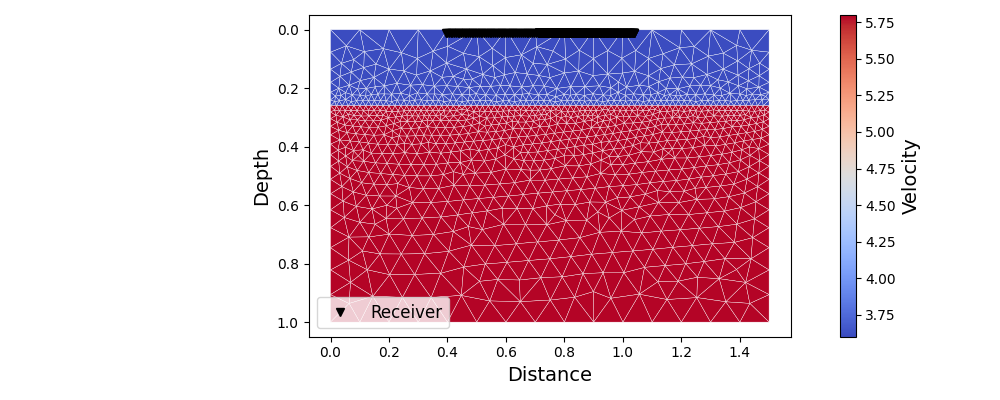

In [32]:
V = 1./slowness  # velocity is more intuitive than slowness

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)

tpc = ax.tripcolor(nodes[:, 0], nodes[:, 1], triangles, V, cmap='coolwarm', edgecolors='w')
ax.plot(surface[:, 0], surface[:, 2], 'kv', label='Receiver')
ax.legend(fontsize=12)
cbar = plt.colorbar(tpc, ax=ax)
cbar.ax.set_ylabel('Velocity', fontsize=14)

ax.invert_yaxis()
ax.set_aspect('equal', 'box')

plt.xlabel('Distance', fontsize=14)
plt.ylabel('Depth', fontsize=14)
plt.tight_layout()

# plt.savefig('figs/example2_model.pdf', bbox_inches='tight')
plt.show()

In [37]:

# create the mesh (values in trangles are unsigned long, we must pass int)

mesh = Mesh2d(nodes, triangles.astype(np.int64), method='SPM', n_secondary=25)

mesh.to_vtk({'slowness': slowness}, 'example2')

# create a source
Tx = np.array([[0.001, 0.26]])

# include surface and interface nodes.  (We drop the y coordinate)
Rx = np.r_[surface[:, ::2], reflector[:, ::2]]

# we can now compute traveltimes and raypaths
tt, rays = mesh.raytrace(Tx, Rx, slowness, return_rays=True)

arrival_times['tt_p'] = tt

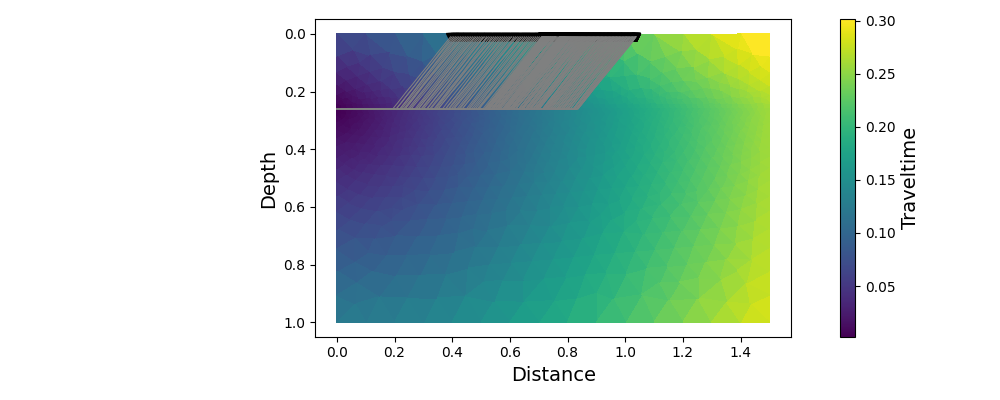

In [38]:
# let's first retrieve traveltimes at the nodes of the mesh
mesh_tt = mesh.get_grid_traveltimes()

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)

tpc = ax.tripcolor(nodes[:, 0], nodes[:, 1], triangles, mesh_tt) #, cmap='coolwarm')
ax.plot(surface[:, 0], surface[:, 2], 'kv')

# add rays for the receivers at the surface
nRx = surface.shape[0]
for r in rays[:nRx]:
    plt.plot(r[:,0], r[:,1], c=[0.5, 0.5, 0.5], lw=0.75)
    
ax.invert_yaxis()
ax.set_aspect('equal', 'box')

cbar = plt.colorbar(tpc, ax=ax)
cbar.ax.set_ylabel('Traveltime', fontsize=14)

plt.xlabel('Distance', fontsize=14)
plt.ylabel('Depth', fontsize=14)
plt.tight_layout()

# plt.savefig('figs/example2_rays.pdf', bbox_inches='tight')

plt.show()

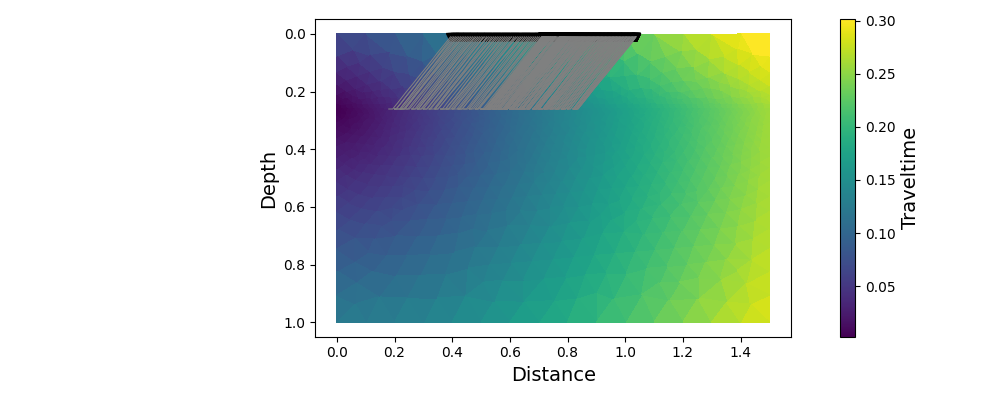

In [39]:
# first column is arrival time, 2nd & 3rd columns at x & z
Tx = np.c_[tt[nRx:].reshape(-1, 1), reflector[:, ::2]]
Rx = surface[:, ::2]

# use aggregate_src to treat all Tx nodes as a single source
tt2, rays2 = mesh.raytrace(Tx, Rx, slowness, return_rays=True, aggregate_src=True)

arrival_times['tt2_p'] = tt2

mesh_tt = mesh.get_grid_traveltimes()

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)

tpc = ax.tripcolor(nodes[:, 0], nodes[:, 1], triangles, mesh_tt) # , cmap='coolwarm')
ax.plot(surface[:, 0], surface[:, 2], 'kv')

# add rays
for r in rays2:
    plt.plot(r[:,0], r[:,1], c=[0.5, 0.5, 0.5], lw=0.75)
    
ax.invert_yaxis()
ax.set_aspect('equal', 'box')

cbar = plt.colorbar(tpc, ax=ax)
cbar.ax.set_ylabel('Traveltime', fontsize=14)

plt.xlabel('Distance', fontsize=14)
plt.ylabel('Depth', fontsize=14)
plt.tight_layout()
# plt.savefig('figs/example2_rays2.pdf', bbox_inches='tight')

plt.show()

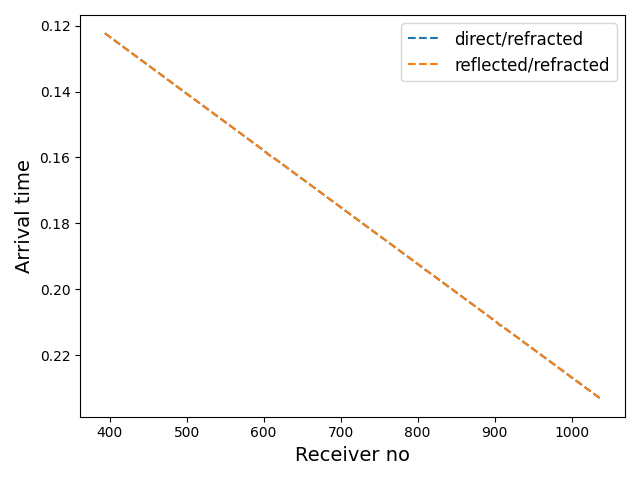

In [222]:
fig,ax =plt.subplots()

ax.plot(distances_sorted,tt[:nRx], '--', label='direct/refracted')
ax.plot(distances_sorted,tt2, '--', label='reflected/refracted')
ax.legend(fontsize=12)

ax.invert_yaxis()
ax.set_xlabel('Receiver no', fontsize=14)
ax.set_ylabel('Arrival time', fontsize=14)
plt.tight_layout()
# plt.savefig('figs/example2_tt.pdf', bbox_inches='tight')

plt.show()

In [162]:
event_num = 44
event_datetime = datetime.datetime.fromtimestamp(np.min(all_picks['Event '+str(event_num)][1]), tz=datetime.timezone.utc)
wanted_file_str = 'Eastwind_decimator_2024-12-'+str(event_datetime.day)+'_'+event_datetime.strftime("%H")+"."+event_datetime.strftime("%M")+"*"

file = glob('/mnt/'+wanted_file_str)[0]

f = h5py.File(file)

attrs = f['Acquisition'].attrs
fs = attrs['PulseRate']
data = f['Acquisition']['Raw[0]']['RawData'][:]
this_time = f['Acquisition']['Raw[0]']['RawDataTime'][:]
times = sintela_to_datetime(this_time)
x = np.linspace(0,data.shape[1],data.shape[1]) * attrs['SpatialSamplingInterval']

bp_top = 500
bp_bottom = 2
downsample_rate = int(fs/bp_top)
#filter by freq
sos = signal.butter(10, [bp_bottom,bp_top], 'bp', fs=fs, output='sos')
filtered = signal.sosfiltfilt(sos, data, axis=0)
# #FK filter
# new_format_times = time_fixer_4_fk(times)
# dims = ('time', 'distance')
# patch = dc.Patch(data=filtered, coords=dict(time=[np.datetime64(i) for i in new_format_times], distance=x), dims=dims)
# filt_cutoffs = np.array([0, 3500, 4500,np.inf]) # try to just filter for the p-wave

# fk_filtered = patch.slope_filter(filt=filt_cutoffs)
# fk_filtered_data = np.array(fk_filtered.data)

#normalize
data_normed_filtered = chan_norm(filtered)

t_start = times[0].replace(tzinfo = datetime.timezone.utc)
source_time = datetime.datetime.fromtimestamp(np.median(event_location[:,3]), tz=datetime.timezone.utc)
slice_start = int(((source_time - t_start).total_seconds()) * fs)
slice_end = int(((source_time - t_start).total_seconds() + 5) * fs)


event_data = data_normed_filtered[slice_start:slice_end,:]
t_event = times[slice_start:slice_end]

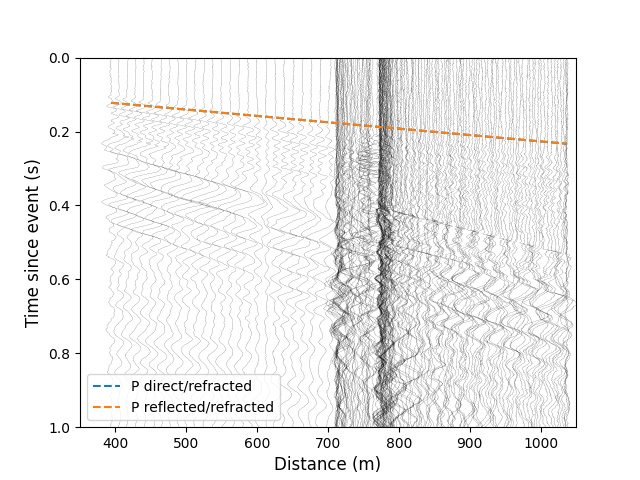

In [224]:
fig,ax = plt.subplots()
for n in np.arange(0,len(distances_sorted),2):
    ax.plot(distances_sorted[n]+event_data[:,np.argsort(distances)][:,n], [i.total_seconds() for i in t_event - t_event[0]], '-k',lw=.1)

ax.plot(distances_sorted,arrival_times['tt_p'][:nRx], '--', label='P direct/refracted')
ax.plot(distances_sorted,arrival_times['tt2_p'], '--', label='P reflected/refracted')
# ax.plot(distances_sorted,arrival_times['tt_s'][:nRx], '--', label='S direct/refracted')
# ax.plot(distances_sorted,arrival_times['tt2_s'], '--', label='S reflected/refracted')
# ax.plot(distances_sorted,arrival_times['tt_r'][:nRx], '--', label='Rayleigh direct/refracted')
# ax.plot(distances_sorted,arrival_times['tt2_r'], '--', label='Rayleigh reflected/refracted')

# vel=(1036.9765126491482-393)/(1.132616-0.974035)
# ax.plot([393,1036.9765126491482],
#         [0.974035, 1.132616], ls='--', lw=1, label=str(round(vel)))

# vel=(1036.9765126491482-393)/(1.47881-1.082502)
# ax.plot([393,1036.9765126491482],
#         [1.082502, 1.47881], ls='--', lw=1, label=str(round(vel)))

# vel=(1036.9765126491482-393)/(1.407-1.0813)
# ax.plot([393,1036.9765126491482],
#         [1.0813, 1.407], ls='--', lw=1, label=str(round(vel)))

# vel=(1036.9765126491482-393)/(1.9370-1.53435)
# ax.plot([393,1036.9765126491482],
#         [1.5343, 1.9370], ls='--', lw=1, label=str(round(vel)))

ax.set_ylabel('Time since event (s)', fontsize=12)
ax.set_xlabel('Distance (m)', fontsize=12)

ax.set_ylim([0,1])
ax.set_xlim([350,1050])

ax.legend(loc='lower left', fontsize=10)
ax.invert_yaxis()

# plt.savefig('../Figures/event_44_traveltime_fit.png', bbox_inches='tight')

# Trying with a 3 layer model

In [33]:
import gmsh

gmsh.initialize()
gmsh.clear()

mesh_size = 0.1
mesh_size2 = 0.2 * mesh_size
mesh_size3 = 0.2 * mesh_size

# -------------------------
# TOP SURFACE
# -------------------------
p1 = gmsh.model.geo.addPoint(0.0, 0.0, 0.0, meshSize=mesh_size)
p2 = gmsh.model.geo.addPoint(0.3, 0.0, 0.0, meshSize=mesh_size)
p3 = gmsh.model.geo.addPoint(1.5, 0.0, -0.001, meshSize=mesh_size)
p4 = gmsh.model.geo.addPoint(3.0, 0.0, 0.001, meshSize=mesh_size)
p5 = gmsh.model.geo.addPoint(4.2, 0.0, 0.0, meshSize=mesh_size)
p6 = gmsh.model.geo.addPoint(4.5, 0.0, 0.0, meshSize=mesh_size)

# -------------------------
# INTERFACE 1
# -------------------------
p7  = gmsh.model.geo.addPoint(4.5, 0.0, 0.04,   meshSize=mesh_size2)
p8  = gmsh.model.geo.addPoint(3.0, 0.0, 0.039, meshSize=mesh_size2)
p9  = gmsh.model.geo.addPoint(1.5, 0.0, 0.041, meshSize=mesh_size2)
p10 = gmsh.model.geo.addPoint(0.0, 0.0, 0.04,   meshSize=mesh_size2)

# -------------------------
# INTERFACE 2  <-- new
# -------------------------
p13 = gmsh.model.geo.addPoint(4.5, 0.0, 0.3,  meshSize=mesh_size3)
p14 = gmsh.model.geo.addPoint(3.0, 0.0, 0.299, meshSize=mesh_size3)
p15 = gmsh.model.geo.addPoint(1.5, 0.0, 0.301, meshSize=mesh_size3)
p16 = gmsh.model.geo.addPoint(0.0, 0.0, 0.3,  meshSize=mesh_size3)

# -------------------------
# BOTTOM
# -------------------------
p11 = gmsh.model.geo.addPoint(4.5, 0.0, 1.0, meshSize=mesh_size)
p12 = gmsh.model.geo.addPoint(0.0, 0.0, 1.0, meshSize=mesh_size)

# -------------------------
# CURVES
# -------------------------
# top boundary
surf_tag = gmsh.model.geo.addBSpline([p1, p2, p3, p4, p5, p6], tag=10)

# interface 1
gmsh.model.geo.addLine(p6, p7, tag=11)
refl1_tag = gmsh.model.geo.addBSpline([p7, p8, p9, p10], tag=12)
gmsh.model.geo.addLine(p10, p1, tag=13)

# interface 2
gmsh.model.geo.addLine(p7, p13, tag=14)
refl2_tag = gmsh.model.geo.addBSpline([p13, p14, p15, p16], tag=15)
gmsh.model.geo.addLine(p16, p10, tag=16)

# bottom
gmsh.model.geo.addLine(p13, p11, tag=17)
gmsh.model.geo.addLine(p11, p12, tag=18)
gmsh.model.geo.addLine(p12, p16, tag=19)

# -------------------------
# SURFACE LOOPS
# -------------------------
# layer 1: between top surface and interface 1
gmsh.model.geo.addCurveLoop([10, 11, 12, 13], tag=21)

# layer 2: between interface 1 and interface 2
gmsh.model.geo.addCurveLoop([-12, 14, 15, 16], tag=22)

# layer 3: between interface 2 and bottom
gmsh.model.geo.addCurveLoop([-15, 17, 18, 19], tag=23)

# -------------------------
# PLANE SURFACES
# -------------------------
gmsh.model.geo.addPlaneSurface([21], tag=31)
gmsh.model.geo.addPlaneSurface([22], tag=32)
gmsh.model.geo.addPlaneSurface([23], tag=33)

gmsh.model.geo.synchronize()

# -------------------------
# PHYSICAL GROUPS
# -------------------------
pl1 = gmsh.model.addPhysicalGroup(1, [surf_tag])
pl2 = gmsh.model.addPhysicalGroup(1, [refl1_tag])
pl3 = gmsh.model.addPhysicalGroup(1, [refl2_tag])

ps1 = gmsh.model.addPhysicalGroup(2, [31])
ps2 = gmsh.model.addPhysicalGroup(2, [32])
ps3 = gmsh.model.addPhysicalGroup(2, [33])

gmsh.model.setPhysicalName(1, pl1, "surface")
gmsh.model.setPhysicalName(1, pl2, "reflector_1")
gmsh.model.setPhysicalName(1, pl3, "reflector_2")

gmsh.model.setPhysicalName(2, ps1, "layer_1")
gmsh.model.setPhysicalName(2, ps2, "layer_2")
gmsh.model.setPhysicalName(2, ps3, "layer_3")

# -------------------------
# GENERATE 2D MESH
# -------------------------
gmsh.model.mesh.generate(2)

# Optional:
# gmsh.fltk.run()

# gmsh.finalize()

Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 10 (Nurb)
Info    : [ 20%] Meshing curve 11 (Line)
Info    : [ 30%] Meshing curve 12 (Nurb)
Info    : [ 40%] Meshing curve 13 (Line)
Info    : [ 50%] Meshing curve 14 (Line)
Info    : [ 60%] Meshing curve 15 (Nurb)
Info    : [ 70%] Meshing curve 16 (Line)
Info    : [ 80%] Meshing curve 17 (Line)
Info    : [ 90%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 19 (Line)
Info    : Done meshing 1D (Wall 0.0215287s, CPU 0.020228s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 31 (Plane, Frontal-Delaunay)
Info    : [ 40%] Meshing surface 32 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 33 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.362916s, CPU 0.359421s)
Info    : 5772 nodes 11992 elements


In [34]:
arrival_times = {}

In [35]:
slowness = []
triangles = []

surface = []        # node coordinates at the surface
reflector1 = []    # node coordinates at interface 1
reflector2 = []    # node coordinates at interface 2

for dim, tag in gmsh.model.getEntities():

    if dim == 1:
        # get the nodes on the BSplines
        elemTypes, elemTags, elemNodeTags = gmsh.model.mesh.getElements(dim, tag)
        physicalTags = gmsh.model.getPhysicalGroupsForEntity(dim, tag)
        if len(physicalTags) == 0:
            continue

        name = gmsh.model.getPhysicalName(dim, physicalTags[0])

        if name == "surface":
            for node_tag in np.unique(elemNodeTags[0]):
                node = gmsh.model.mesh.getNode(node_tag)
                surface.append(node[0])

        elif name == "reflector_1":
            for node_tag in np.unique(elemNodeTags[0]):
                node = gmsh.model.mesh.getNode(node_tag)
                reflector1.append(node[0])

        elif name == "reflector_2":
            for node_tag in np.unique(elemNodeTags[0]):
                node = gmsh.model.mesh.getNode(node_tag)
                reflector2.append(node[0])

    elif dim == 2:
        # assign velocity/slowness to each triangle
        elemTypes, elemTags, elemNodeTags = gmsh.model.mesh.getElements(dim, tag)
        physicalTags = gmsh.model.getPhysicalGroupsForEntity(dim, tag)
        if len(physicalTags) == 0:
            continue

        name = gmsh.model.getPhysicalName(dim, physicalTags[0])

        for n in range(len(elemTags[0])):
            t = elemNodeTags[0][3*n:(3*n+3)]
            triangles.append(t)
            ## P-wave velocities ###
            if name == "layer_1":
                slowness.append(1 / .9)
            elif name == "layer_2":
                slowness.append(1 / 3.8)
            elif name == "layer_3":
                slowness.append(1 / 5.)   # choose your third-layer velocity

            ### s-wave velocities ###
            # if name == "layer_1":
            #     slowness.append(1 / .6)
            # elif name == "layer_2":
            #     slowness.append(1 / 1.8)
            # elif name == "layer_3":
            #     slowness.append(1 / 2.8)   # choose your third-layer velocity

In [36]:
help(gmsh.model.mesh.getNode)

Help on function getNode in module gmsh:

getNode(nodeTag)
    gmsh.model.mesh.getNode(nodeTag)
    
    Get the coordinates and the parametric coordinates (if any) of the node
    with tag `tag', as well as the dimension `dim' and tag `tag' of the entity
    on which the node is classified. This function relies on an internal cache
    (a vector in case of dense node numbering, a map otherwise); for large
    meshes accessing nodes in bulk is often preferable.
    
    Return `coord', `parametricCoord', `dim', `tag'.
    
    Types:
    - `nodeTag': size
    - `coord': vector of doubles
    - `parametricCoord': vector of doubles
    - `dim': integer
    - `tag': integer



In [1]:
slowness = np.array(slowness, dtype=float)
triangles = np.array(triangles, dtype=int)

DAS_channels = np.vstack((
    distances_sorted / 1000,
    np.zeros(len(distances_sorted)),
    0.01 * np.ones(len(distances_sorted))
)).T

reflector1 = np.array(reflector1)
reflector2 = np.array(reflector2)

reflector = np.vstack((reflector1, reflector2))

uniqueTags = np.unique(triangles).astype(int)

equiv = np.empty(int(uniqueTags.max()) + 1, dtype=int)
nodes = []

for n, tag in enumerate(uniqueTags):
    equiv[tag] = n
    node = gmsh.model.mesh.getNode(int(tag))
    nodes.append(node[0])

# remap triangle node tags to compact indices
triangles = equiv[triangles]

nodes = np.array(nodes)
nodes = np.c_[nodes[:, 0], nodes[:, 2]]   # keep only x and z

# sort coordinates for plotting
DAS_channels = DAS_channels[np.argsort(DAS_channels[:, 0])]

if len(reflector1) > 0:
    reflector1 = reflector1[np.argsort(reflector1[:, 0])]

if len(reflector2) > 0:

    reflector2 = reflector2[np.argsort(reflector2[:, 0])]

gmsh.finalize()

NameError: name 'np' is not defined

/tmp/ipykernel_1453142/940945057.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/opt/conda/lib/python3.10/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


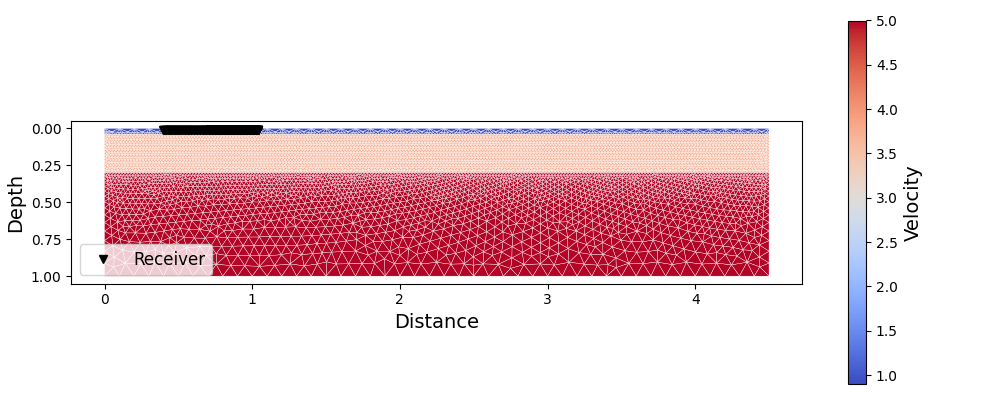

In [38]:
V = 1./slowness  # velocity is more intuitive than slowness

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)

tpc = ax.tripcolor(nodes[:, 0], nodes[:, 1], triangles, V, cmap='coolwarm', edgecolors='w')
ax.plot(DAS_channels[:, 0], DAS_channels[:, 2], 'kv', label='Receiver')
ax.legend(fontsize=12)
cbar = plt.colorbar(tpc, ax=ax)
cbar.ax.set_ylabel('Velocity', fontsize=14)

ax.invert_yaxis()
ax.set_aspect('equal', 'box')

plt.xlabel('Distance', fontsize=14)
plt.ylabel('Depth', fontsize=14)
plt.tight_layout()

# plt.savefig('figs/example2_model.pdf', bbox_inches='tight')
plt.show()

In [39]:

# create the mesh (values in trangles are unsigned long, we must pass int)

mesh = Mesh2d(nodes, triangles.astype(np.int64), method='SPM', n_secondary=25)

mesh.to_vtk({'slowness': slowness}, 'example2')

# create a source
Tx = np.array([[0.1, 0.04]]) # Surface source (snow/ice interface)
# Tx = np.array([[0.001, 0.3]]) # Ice bed interface, at the x of the located event
# Tx = np.array([[0.1, 0.15]]) # Ice bed interface

# include surface and interface nodes.  (We drop the y coordinate)
### ORIGINAL
Rx = np.r_[DAS_channels[:, ::2], reflector[:, ::2]]
### TWO INTERFACES
# Rx = np.r_[surface[:, ::2], reflector1[:, ::2], reflector2[:, ::2]]

# we can now compute traveltimes and raypaths
tt, rays = mesh.raytrace(Tx, Rx, slowness, return_rays=True)

arrival_times['tt_p'] = tt

: 

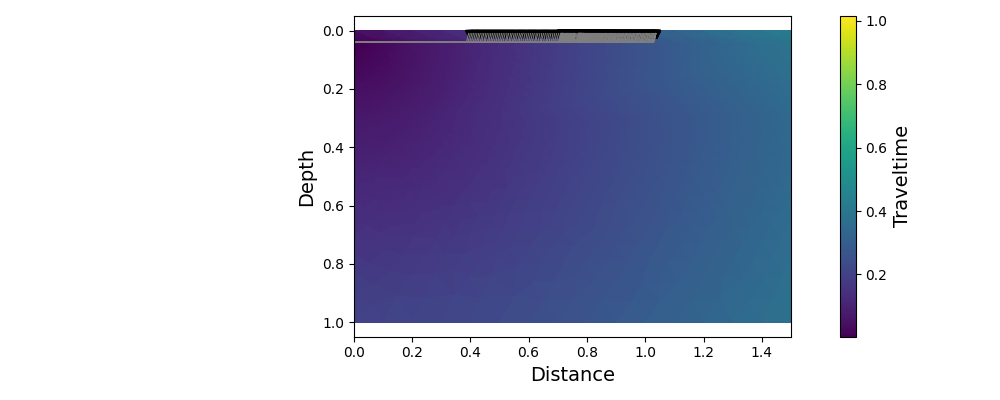

In [ ]:
# let's first retrieve traveltimes at the nodes of the mesh
mesh_tt = mesh.get_grid_traveltimes()

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)

tpc = ax.tripcolor(nodes[:, 0], nodes[:, 1], triangles, mesh_tt) #, cmap='coolwarm')
ax.plot(DAS_channels[:, 0], DAS_channels[:, 2], 'kv')

# add rays for the receivers at the surface
nRx = DAS_channels.shape[0]
nRx1 = reflector1.shape[0]
for r in rays[:nRx]:
    plt.plot(r[:,0], r[:,1], c=[0.5, 0.5, 0.5], lw=0.75)


ax.set_xlim([0, 1.5])    
ax.invert_yaxis()
ax.set_aspect('equal', 'box')

cbar = plt.colorbar(tpc, ax=ax)
cbar.ax.set_ylabel('Traveltime', fontsize=14)

plt.xlabel('Distance', fontsize=14)
plt.ylabel('Depth', fontsize=14)
plt.tight_layout()

ax.set_xlim([0, 1.5])
# plt.savefig('figs/example2_rays.pdf', bbox_inches='tight')

plt.show()

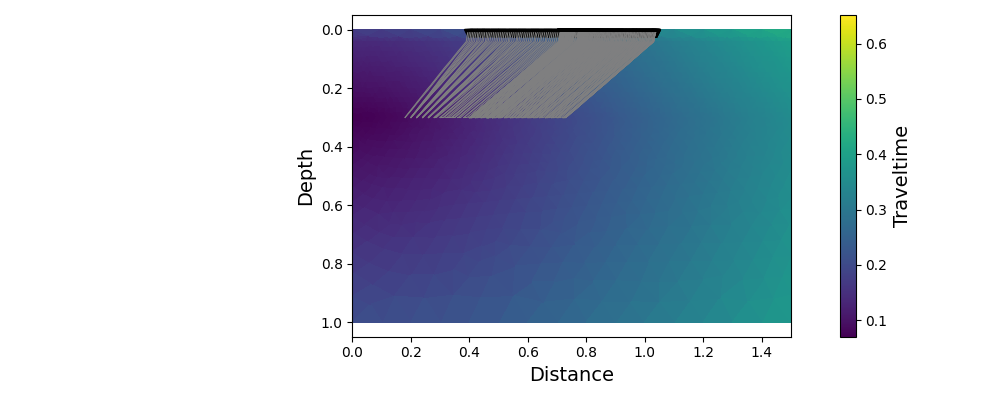

In [ ]:
# first column is arrival time, 2nd & 3rd columns at x & z
### Oringinal
Tx = np.c_[tt[nRx+nRx1:].reshape(-1, 1)[::-1], reflector2[:, ::2]]
### Updated for two interfaces (not working)
# Tx = np.c_[tt[nRx:].reshape(-1, 1), reflector1[:, ::2], reflector2[:, ::2]]

Rx = DAS_channels[:, ::2]

# use aggregate_src to treat all Tx nodes as a single source
tt2, rays2 = mesh.raytrace(Tx, Rx, slowness, return_rays=True, aggregate_src=True)

arrival_times['tt2_p'] = tt2

mesh_tt = mesh.get_grid_traveltimes()

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)

tpc = ax.tripcolor(nodes[:, 0], nodes[:, 1], triangles, mesh_tt) # , cmap='coolwarm')
ax.plot(DAS_channels[:, 0], DAS_channels[:, 2], 'kv')

ax.set_xlim([0, 1.5])
# add rays
for r in rays2:
    plt.plot(r[:,0], r[:,1], c=[0.5, 0.5, 0.5], lw=0.75)
    
ax.invert_yaxis()
ax.set_aspect('equal', 'box')

cbar = plt.colorbar(tpc, ax=ax)
cbar.ax.set_ylabel('Traveltime', fontsize=14)

plt.xlabel('Distance', fontsize=14)
plt.ylabel('Depth', fontsize=14)
plt.tight_layout()
# plt.savefig('figs/example2_rays2.pdf', bbox_inches='tight')

plt.show()

In [ ]:
# # first column is arrival time, 2nd & 3rd columns at x & z
# ### Oringinal
# Tx = np.c_[tt2[nRx+nRx1:].reshape(-1, 1)[::-1], reflector2[:, ::2]]
# ### Updated for two interfaces (not working)
# # Tx = np.c_[tt[nRx:].reshape(-1, 1), reflector1[:, ::2], reflector2[:, ::2]]

# Rx = DAS_channels[:, ::2]

# # use aggregate_src to treat all Tx nodes as a single source
# tt2, rays2 = mesh.raytrace(Tx, Rx, slowness, return_rays=True, aggregate_src=True)

# arrival_times['tt2_p_2'] = tt2

# mesh_tt = mesh.get_grid_traveltimes()

# fig = plt.figure(figsize=(10, 4))
# ax = fig.add_subplot(111)

# tpc = ax.tripcolor(nodes[:, 0], nodes[:, 1], triangles, mesh_tt) # , cmap='coolwarm')
# ax.plot(DAS_channels[:, 0], DAS_channels[:, 2], 'kv')

# ax.set_xlim([0, 1.5])
# # add rays
# for r in rays2:
#     plt.plot(r[:,0], r[:,1], c=[0.5, 0.5, 0.5], lw=0.75)
    
# ax.invert_yaxis()
# ax.set_aspect('equal', 'box')

# cbar = plt.colorbar(tpc, ax=ax)
# cbar.ax.set_ylabel('Traveltime', fontsize=14)

# plt.xlabel('Distance', fontsize=14)
# plt.ylabel('Depth', fontsize=14)
# plt.tight_layout()
# # plt.savefig('figs/example2_rays2.pdf', bbox_inches='tight')

# plt.show()

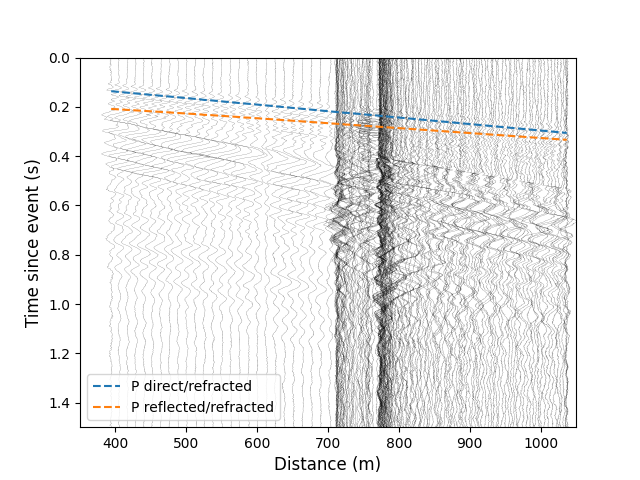

In [ ]:
fig,ax = plt.subplots()
for n in np.arange(0,len(distances_sorted),2):
    ax.plot(distances_sorted[n]+event_data[:,np.argsort(distances)][:,n], 
            [i.total_seconds() for i in t_event - t_event[0]]
            , '-k',lw=.1)

ax.plot(distances_sorted,arrival_times['tt_p'][:nRx], '--', label='P direct/refracted')
ax.plot(distances_sorted,arrival_times['tt2_p'], '--', label='P reflected/refracted')
# ax.plot(distances_sorted,arrival_times['tt_s'][:nRx], '--', label='S direct/refracted')
# ax.plot(distances_sorted,arrival_times['tt2_s'], '--', label='S reflected/refracted')

# ax.plot(distances_sorted,arrival_times['tt2_P_double']*2, '--', label='P double reflected/refracted')
# ax.plot(distances_sorted,arrival_times['tt_r'][:nRx], '--', label='Rayleigh direct/refracted')
# ax.plot(distances_sorted,arrival_times['tt2_r'], '--', label='Rayleigh reflected/refracted')

# vel=(1036.9765126491482-393)/(1.132616-0.974035)
# ax.plot([393,1036.9765126491482],
#         [0.974035, 1.132616], ls='--', lw=1, label=str(round(vel)))

# vel=(1036.9765126491482-393)/(1.47881-1.082502)
# ax.plot([393,1036.9765126491482],
#         [1.082502, 1.47881], ls='--', lw=1, label=str(round(vel)))

# vel=(1036.9765126491482-393)/(1.407-1.0813)
# ax.plot([393,1036.9765126491482],
#         [1.0813, 1.407], ls='--', lw=1, label=str(round(vel)))

# vel=(1036.9765126491482-393)/(1.9370-1.53435)
# ax.plot([393,1036.9765126491482],
#         [1.5343, 1.9370], ls='--', lw=1, label=str(round(vel)))

ax.set_ylabel('Time since event (s)', fontsize=12)
ax.set_xlabel('Distance (m)', fontsize=12)

ax.set_ylim([0,1.5])
ax.set_xlim([350,1050])

ax.legend(loc='lower left', fontsize=10)
ax.invert_yaxis()

# plt.savefig('../Figures/event_44_traveltime_fit.png', bbox_inches='tight')

# 

- locate all the events manually
- look for the reflections
- simple models